##  Basic Library imports

In [1]:
import os
import pandas as pd 

from utils import download_images

##  Read Train Dataset

In [2]:
DATASET_FOLDER = '../dataset/train_split'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part3.csv'))
# val_set = pd.read_csv(os.path.join(DATASET_FOLDER, '../dataset/val_split.csv'))

In [ ]:
download_images(train_set['image_link'], '../images/train_part3')

  0%|          | 1/19984 [00:09<54:22:30,  9.80s/it]

Remote end closed connection without response
Remote end closed connection without response
<urlopen error [Errno -3] Temporary failure in name resolution>
Remote end closed connection without response
Remote end closed connection without response


  0%|          | 3/19984 [00:32<61:32:21, 11.09s/it]

Remote end closed connection without response


  0%|          | 4/19984 [00:37<48:31:34,  8.74s/it]

Remote end closed connection without response
Remote end closed connection without response
Remote end closed connection without response
Remote end closed connection without response
Remote end closed connection without response
<urlopen error [Errno 104] Connection reset by peer>
<urlopen error [Errno -3] Temporary failure in name resolution>
[Errno 104] Connection reset by peer
<urlopen error [Errno 101] Network is unreachable>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
Remote end closed connection without response
<urlopen error [Errno 101] Network is unreachable>
<urlopen error [Errno 101] Network is unreachable>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>


Process ForkPoolWorker-89:
Process ForkPoolWorker-97:
Process ForkPoolWorker-87:
Process ForkPoolWorker-90:
Process ForkPoolWorker-80:
Process ForkPoolWorker-2:
Process ForkPoolWorker-92:
Process ForkPoolWorker-69:
Process ForkPoolWorker-88:
Process ForkPoolWorker-94:
Process ForkPoolWorker-25:
Process ForkPoolWorker-83:
Process ForkPoolWorker-71:
Process ForkPoolWorker-22:
Process ForkPoolWorker-95:
Process ForkPoolWorker-60:
Process ForkPoolWorker-100:
Process ForkPoolWorker-79:
Process ForkPoolWorker-77:
Process ForkPoolWorker-91:
Process ForkPoolWorker-93:
Process ForkPoolWorker-75:
Process ForkPoolWorker-52:
Process ForkPoolWorker-96:
Traceback (most recent call last):
Process ForkPoolWorker-64:
Process ForkPoolWorker-67:
Process ForkPoolWorker-99:
Process ForkPoolWorker-31:
Process ForkPoolWorker-37:
Process ForkPoolWorker-18:
Process ForkPoolWorker-40:
Process ForkPoolWorker-29:
Process ForkPoolWorker-49:
Process ForkPoolWorker-72:
Process ForkPoolWorker-82:
Process ForkPoolWork

In [3]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, '../images/train_part3', download_images)
print(f"Missing images downloaded: {len(missing)}")



Missing: 61-Piz7+zLL.jpg
Missing: 71S3U04a-6L.jpg
Missing: 71K8NgXvm6L.jpg
Missing: 71Zp+obzLBL.jpg
Missing: 51F8tQy4i2L.jpg
Missing: 61CSaclLYsL.jpg
Missing: 71kgBzp7ZlL.jpg
Missing: 71tGc9TzEJL.jpg
Missing: 71H5T+jtXNL.jpg
Missing: 81yJ38M-yvL.jpg
Missing: 61+dl-GhYQL.jpg
Missing: 612b807oSLL.jpg
Missing: 713UmiJ8XBL.jpg
Missing: 51SW5wS7W9L.jpg
Missing: 811dQvRTpxL.jpg
Missing: 81FJzrs+jmL.jpg
Missing: 81xP5xKJlBL.jpg
Missing: 81HeMJgkKdL.jpg
Missing: 813P3+vJ-tL.jpg
Missing: 81viCar4geL.jpg
Missing: 71QwFF-MXFL.jpg
Missing: 61fyJ0mm+fL.jpg
Missing: 61AHzIiph-L.jpg
Missing: 41kFVTW7AsL.jpg
Missing: 71ORK9TGFsL.jpg
Missing: 31lvEXvREaL.jpg
Missing: 61WACuEHbwL.jpg
Missing: 8173hhUqQ7L.jpg


100%|██████████| 28/28 [00:20<00:00,  1.35it/s]

Missing images downloaded: 28


In [4]:
assert len(os.listdir('../images/train_part1')) > 0

In [5]:
print("Total rows in CSV:", len(train_set))
print("Rows with null image_link:", train_set['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set[train_set['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 19984
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 19788
Unique image filenames (basenames): 19788
Files in image directory: 20481
Sample duplicate basenames:
image_link
71brV+lqbRL.jpg    4
91v0F6tUxGL.jpg    4
61xAa3qIx1S.jpg    4
912cR71VrtL.jpg    3
81zqul01R-L.jpg    3
Name: count, dtype: int64
Image '21GTpRP0VhL.jpg' has multiple prices: [60.99  19.145]
Image '61xcXm+dZBL.jpg' has multiple prices: [6.1  6.59]
Image '514cltc6umL.jpg' has multiple prices: [55.625 45.99 ]
Image '51FvlF+HxbL.jpg' has multiple prices: [26.99 35.99]
Image '61-tQxwP5wL.jpg' has multiple prices: [13.42 12.99]
Image '71brV+lqbRL.jpg' has multiple prices: [ 71.2  118.7  132.95]
Image '916SyB864tL.jpg' has multiple prices: [51.99 24.99]
Image '81m9blfV5sL.jpg' has multiple prices: [3.29 2.19]
Image '81az129yYyL.jpg' has multiple prices: [45.51 66.14]
Image '81LFypkfb9L.jpg' has multiple prices: [39.35 26.38]
Image '81KsnUVyaXL.jpg' has multiple prices: [2

####  There are some rows that do not have an image at all.

Let's remove them

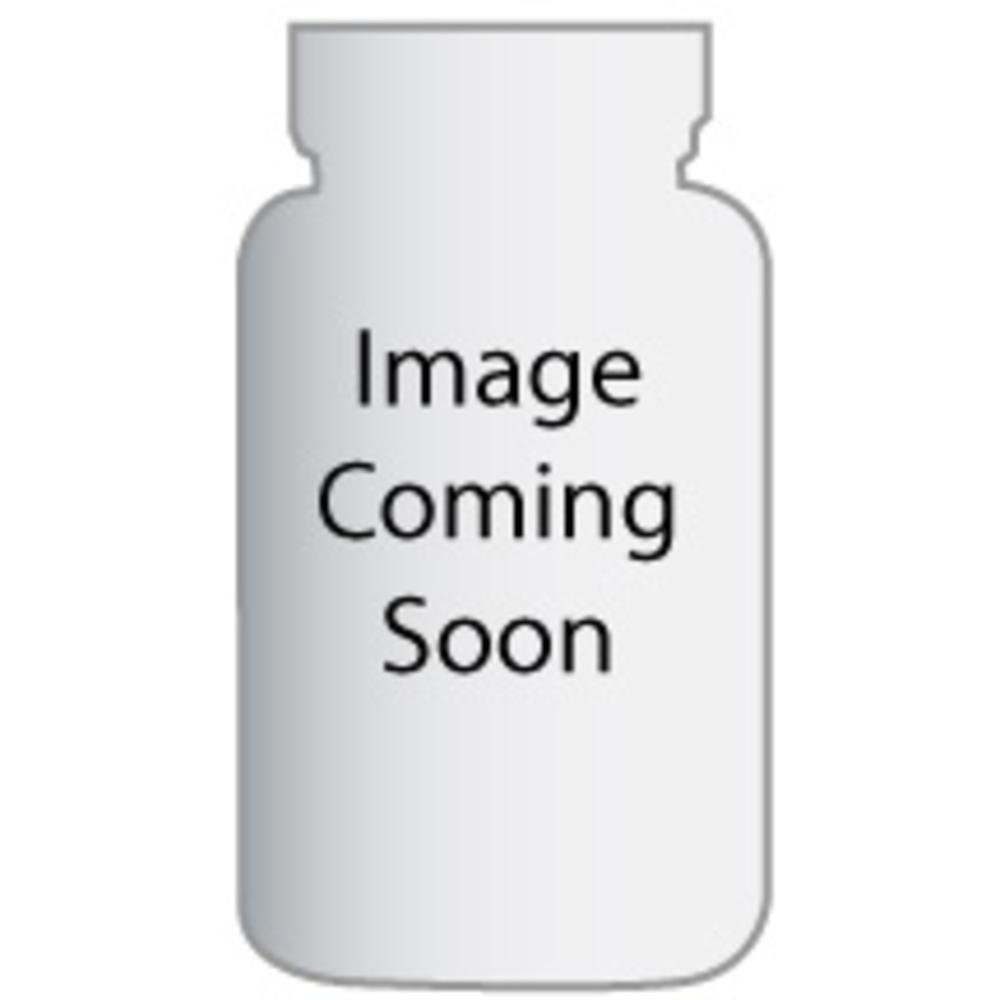

In [16]:
from IPython.display import Image, display

image_path = os.path.join('../images/train_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [17]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 16 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 10 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 16 rows removed.


In [7]:
import zipfile

images_dir = '../images/train_part3'
zip_path = '../train_part3.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../train_part3.zip


In [ ]:
# rm -rf ../images

##  Read Val Dataset

In [2]:
DATASET_FOLDER = '../dataset/val_split'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part2.csv'))

In [3]:
download_images(train_set['image_link'], '../images/val_part2')

 11%|█         | 553/4997 [00:36<02:44, 27.09it/s] 

<urlopen error [Errno -3] Temporary failure in name resolution>


 24%|██▎       | 1186/4997 [01:49<03:55, 16.20it/s]

<urlopen error [Errno 101] Network is unreachable>


100%|██████████| 4997/4997 [02:49<00:00, 29.51it/s]


In [ ]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, '../images/val_part2', download_images)
print(f"Missing images downloaded: {len(missing)}")

0it [00:00, ?it/s]

Missing images downloaded: 0


In [4]:
print("Total rows in CSV:", len(train_set))
print("Rows with null image_link:", train_set['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set[train_set['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 5000
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 4982
Unique image filenames (basenames): 4982
Files in image directory: 20481
Sample duplicate basenames:
image_link
51m1gdQJW2L.jpg    3
71er+W+5lnL.jpg    2
81muciARy6L.jpg    2
81N6JIxAsYL.jpg    2
414iM3z+xjL.jpg    2
Name: count, dtype: int64
Image '71er+W+5lnL.jpg' has multiple prices: [18.785 67.31 ]
Image '81muciARy6L.jpg' has a single price: 12.99
Image '414iM3z+xjL.jpg' has multiple prices: [74.41  48.995]
Image '81N6JIxAsYL.jpg' has multiple prices: [2.44 2.99]
Image '71lcWW2OoIL.jpg' has multiple prices: [31.99 18.99]
Image '51VbyH2h9OL.jpg' has multiple prices: [41.11 22.9 ]
Image '716FfNj62KL.jpg' has multiple prices: [11.82 21.24]
Image '81HmNPEbDpL.jpg' has multiple prices: [20.28 12.12]
Image '81059CYd4tL.jpg' has multiple prices: [ 3.11 14.99]
Image '81lyaVt9X5L.jpg' has multiple prices: [28.27 78.86]
Image '71qMAorsalL.jpg' has a single price: 27.56
Image '61wtspdhb

####  There are some rows that do not have an image at all.

Let's remove them

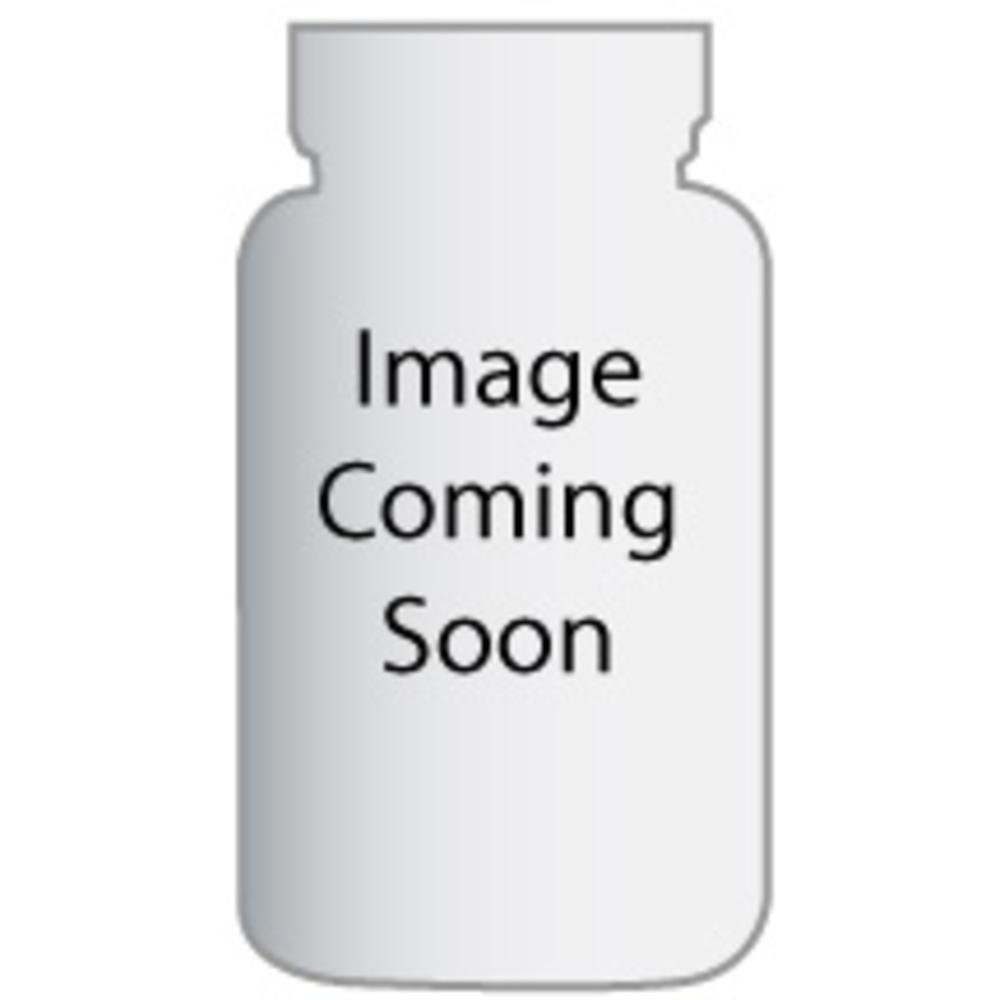

In [5]:
from IPython.display import Image, display

image_path = os.path.join('../images/val_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [6]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 3 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 3 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 4 rows removed.


#### Save the folder as a ZIP File

In [ ]:
import zipfile

images_dir = '../images/val_part2'
zip_path = '../val_part2.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../val_part1.zip
